# Valley Width Extraction Example

This notebook demonstrates the full valley-width extraction pipeline using
the **ValleyWidthIdentifyer** package (Python translation of the MATLAB
ElevationThresholdValleyWidth toolbox) together with the Python **topotoolbox** package.

The example uses the **Big Tujunga** DEM bundled with topotoolbox.

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

import topotoolbox as topo

# Add project root to path so we can import ValleyWidthIdentifyer
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import ValleyWidthIdentifyer as vwi

## 1. Load DEM

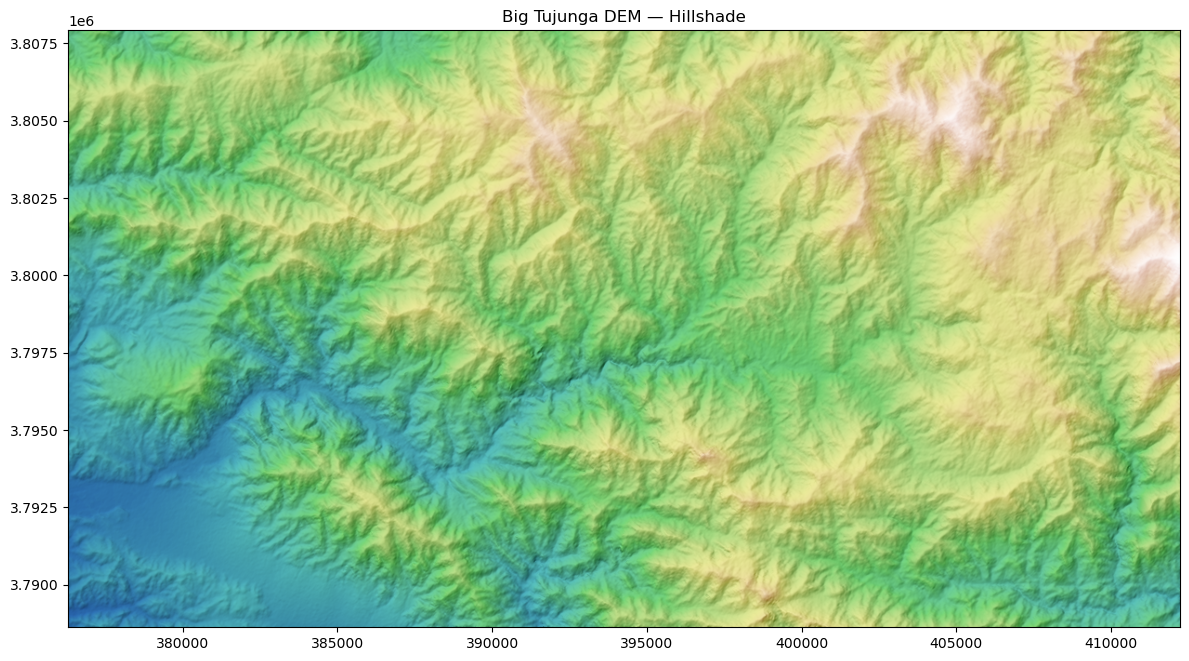

DEM shape: (643, 1197)
Cell size: 30.0 m


In [9]:
dem = topo.load_dem('bigtujunga')

fig, ax = plt.subplots(figsize=(12, 8))
dem.plot_hs(ax=ax, cmap='gist_earth',
            norm=colors.Normalize(vmin=0, vmax=np.nanmax(np.asarray(dem))))
ax.set_title('Big Tujunga DEM — Hillshade')
plt.tight_layout()
plt.show()

print(f'DEM shape: {dem.shape}')
print(f'Cell size: {dem.cellsize} m')

## 2. Flow Routing and Stream Network

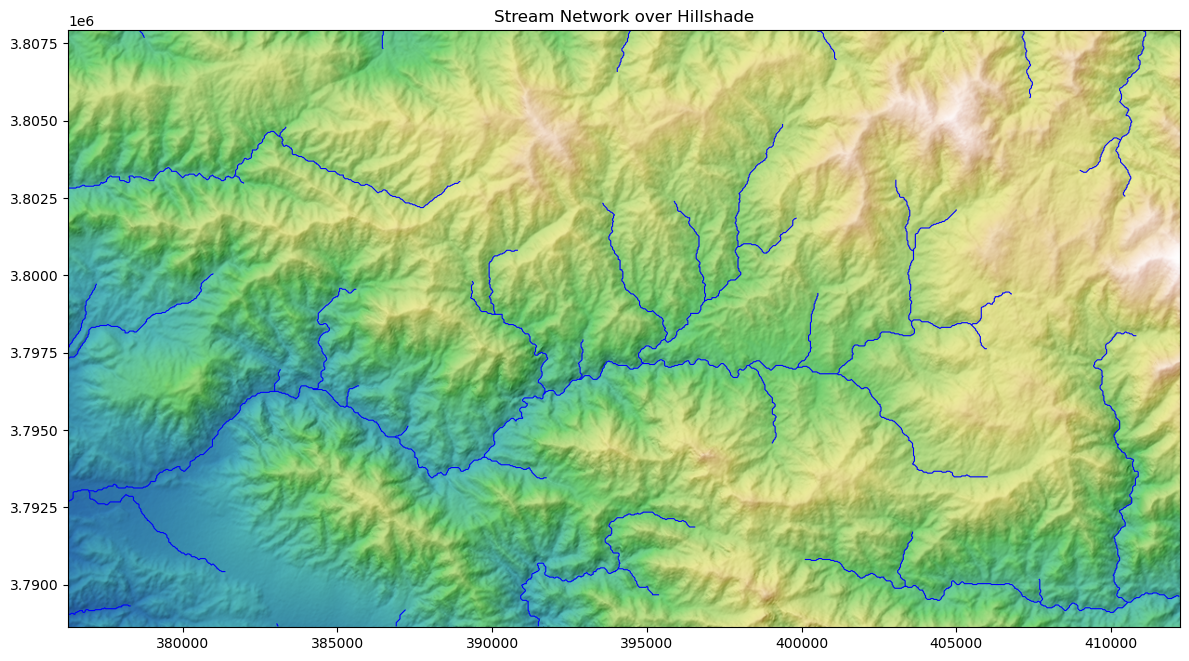

In [10]:
fd = topo.FlowObject(dem)
A = fd.flow_accumulation()

# Stream threshold — adjust based on DEM resolution and area
stream_threshold = 5000  #threshold area
S = topo.StreamObject(fd, threshold=stream_threshold, units='pixels')

fig, ax = plt.subplots(figsize=(12, 8))
dem.plot_hs(ax=ax, cmap='gist_earth',
            norm=colors.Normalize(vmin=0, vmax=np.nanmax(np.asarray(dem))))
S.plot(ax=ax, color='blue', linewidth=0.8)
ax.set_title('Stream Network over Hillshade')
plt.tight_layout()
plt.show()

## 3. Run the Valley Width Pipeline

The `dem2widths` function performs all steps:
1. Flow routing and stream extraction
2. Removal of short streams
3. Valley classification (HAND threshold)
4. Cross-stream swath profile generation
5. Valley width measurement from swath profiles
6. Drainage area and gradient extraction at each width point

### Parameter guide

- **`streamarea`** — Drainage area threshold for defining streams, in the chosen `units` (default: pixels). **Larger** values produce fewer, larger streams (only major channels). **Smaller** values create a denser network that includes smaller tributaries, yielding more width measurements but also more noise.

- **`elevthreshold`** — Maximum height above the nearest stream (m) for a pixel to count as "valley". Controls how wide the valley classification extends up the hillslopes. **Larger** values classify more terrain as valley, producing wider measured widths. **Smaller** values restrict the valley to the immediate floodplain/channel belt.

- **`swath_dx`** — Spacing (m) between cross-stream profiles along each stream. **Smaller** values give denser measurement points (higher spatial resolution of width along the stream) but increase computation time. **Larger** values produce fewer, more widely spaced measurements.

- **`minradius`** — Serves two roles: (1) minimum stream length — streams shorter than this are removed; (2) search radius for the moving-minimum smoothing of raw width values. **Larger** values remove more short tributaries and smooth widths over a broader window, reducing local noise. **Smaller** values preserve short streams and retain more local variability.

- **`swath_width_param`** — Total width (m) of the cross-stream profile transects. Should be set wide enough to reach beyond the valley on both sides. If too narrow, profiles may never exit the valley, and width defaults to half this value. If too wide, computation slows without benefit.

In [11]:
# Parameters
streamarea = 5000        # threshold area. larger = fewer/bigger streams only; smaller = denser network
elevthreshold = 20        # larger = wider valleys; smaller = narrower, floodplain-only (m)
swath_dx = 20             # larger = fewer measurements; smaller = denser along-stream (m)
minradius = 100           # larger = more smoothing & removes more short tribs (m)
swath_width_param = 1000  # must exceed expected valley width on both sides combined (m)

allwidths, DV = vwi.dem2widths(
    dem,
    streamarea=streamarea,
    elevthreshold=elevthreshold,
    swath_dx=swath_dx,
    minradius=minradius,
    swath_width_param=swath_width_param,
    units='pixels',
    plot=False
)

print(f'\nOutput shape: {allwidths.shape}')
print(f'Columns: x, y, raw_width, min_width, drainage_area_m2, gradient_deg')
print(f'Number of width measurements: {allwidths.shape[0]}')

Calculating flow directions
Calculating streams
Removing short streams
Classifying valley
Setting up the DEM
Finding DZ (vertical distance to stream)
Valley classification complete
Swath width extraction
Extracting drainage area
Extracting gradients
Done. 10333 width measurements extracted.

Output shape: (10333, 6)
Columns: x, y, raw_width, min_width, drainage_area_m2, gradient_deg
Number of width measurements: 10333


## 4. Visualize Valley Classification

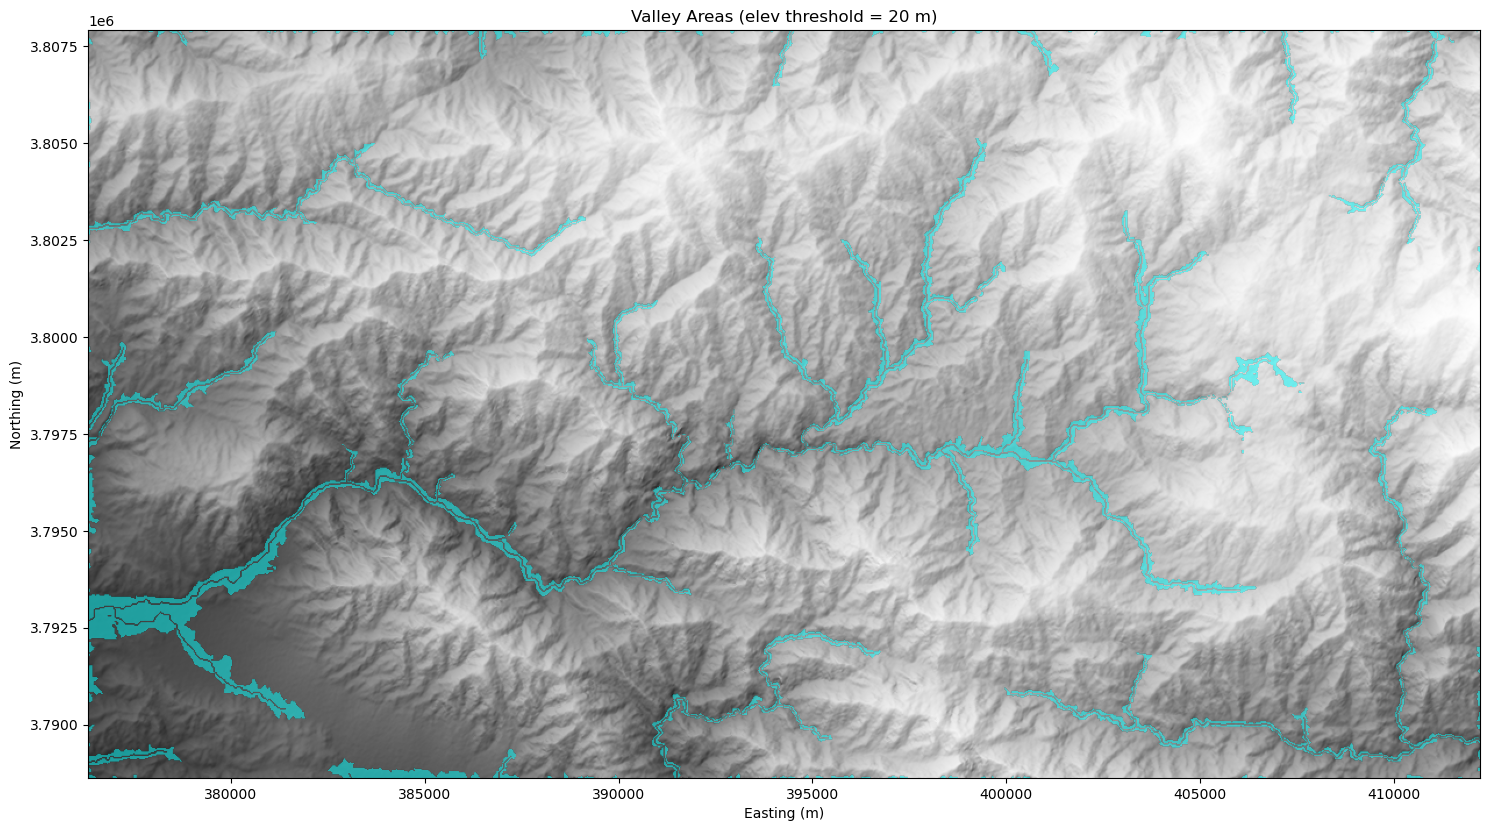

In [12]:
fig, ax = plt.subplots(figsize=(15, 10))

# Hillshade background
dem.plot_hs(ax=ax, cmap='gray',
            norm=colors.Normalize(vmin=0, vmax=np.nanmax(np.asarray(dem))))

# Valley polygon overlay: use cyan color and alpha 0.5
dv_arr = np.asarray(DV.z).copy()
bounds = dem.bounds
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Only plot valleys: mask everything that isn't class 1 (valley)
valley_mask = np.ma.masked_where(dv_arr != 1, dv_arr)
im = ax.imshow(valley_mask, extent=extent, origin='upper',
               cmap=colors.ListedColormap(['cyan']), alpha=0.5, vmin=1, vmax=1.1)

ax.set_title(f'Valley Areas (elev threshold = {elevthreshold} m)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

## 5. Visualize Valley Widths

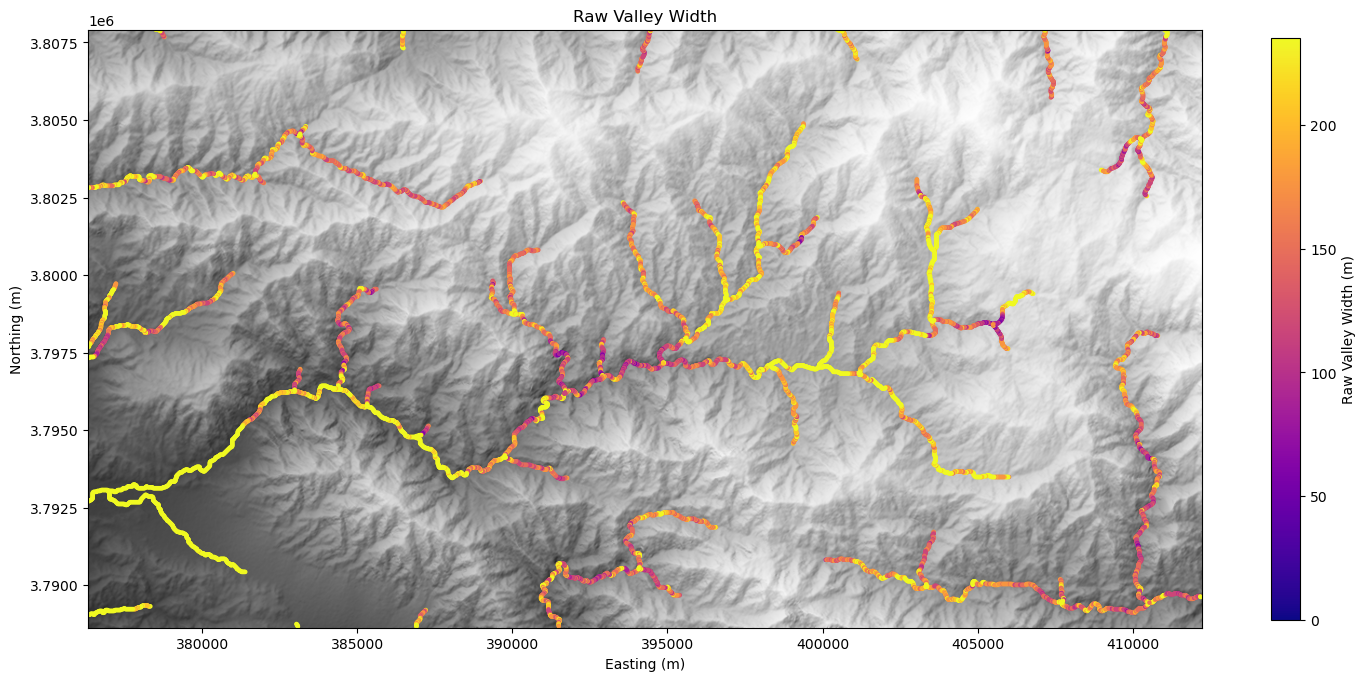

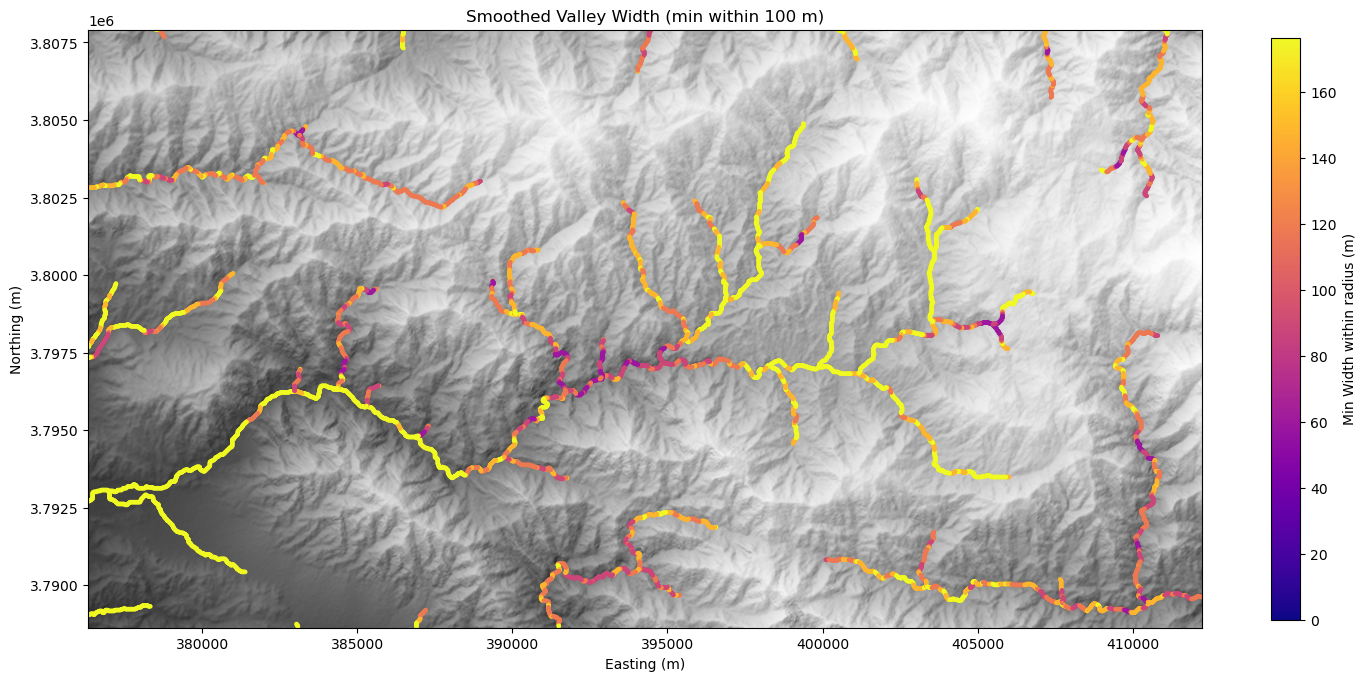

In [13]:
# Make two full-sized, separate plots rather than one with two subplots

# Raw width plot
fig, ax = plt.subplots(figsize=(15, 10))
dem.plot_hs(ax=ax, cmap='gray',
            norm=colors.Normalize(vmin=0, vmax=np.nanmax(np.asarray(dem))))
sc = ax.scatter(allwidths[:, 0], allwidths[:, 1],
                c=allwidths[:, 2], cmap='plasma', s=5,
                vmin=0, vmax=np.percentile(allwidths[:, 2], 75))
plt.colorbar(sc, ax=ax, label='Raw Valley Width (m)', shrink=0.6)
ax.set_title('Raw Valley Width')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()

# Smoothed (min within radius) width plot
fig, ax = plt.subplots(figsize=(15, 10))
dem.plot_hs(ax=ax, cmap='gray',
            norm=colors.Normalize(vmin=0, vmax=np.nanmax(np.asarray(dem))))
sc = ax.scatter(allwidths[:, 0], allwidths[:, 1],
                c=allwidths[:, 3], cmap='plasma', s=5,
                vmin=0, vmax=np.percentile(allwidths[:, 3], 75))
plt.colorbar(sc, ax=ax, label='Min Width within radius (m)', shrink=0.6)
ax.set_title(f'Smoothed Valley Width (min within {minradius} m)')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()